# Pre-trained model (ResNet-18)

Test sample shape: torch.Size([3, 224, 224]), Label: 4
Layer (type (var_name))                  Input Shape               Output Shape              Param #
ResNet (ResNet)                          [32, 3, 224, 224]         [32, 10]                  --
├─Conv2d (conv1)                         [32, 3, 224, 224]         [32, 64, 112, 112]        9,408
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]        [32, 64, 112, 112]        128
├─ReLU (relu)                            [32, 64, 112, 112]        [32, 64, 112, 112]        --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]        [32, 64, 56, 56]          --
├─Sequential (layer1)                    [32, 64, 56, 56]          [32, 64, 56, 56]          --
│    └─BasicBlock (0)                    [32, 64, 56, 56]          [32, 64, 56, 56]          --
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]          [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d (bn1)            [32, 64, 56, 56]          [

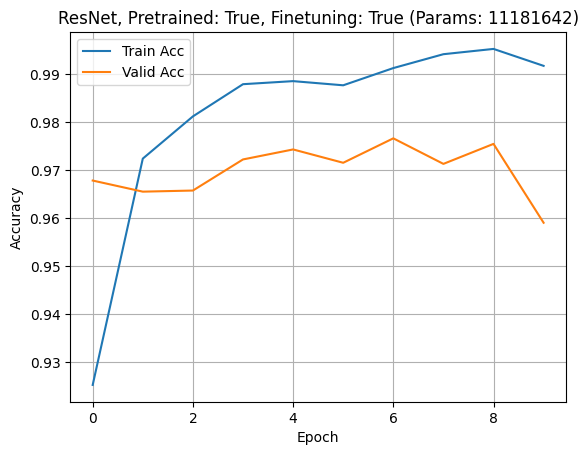

Test Accuracy: 0.964
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       643
           1       0.98      0.99      0.99       522
           2       0.96      0.98      0.97       616
           3       0.99      0.97      0.98       509
           4       1.00      0.87      0.93       529
           5       1.00      0.94      0.97       405
           6       0.97      0.94      0.95       483
           7       0.90      1.00      0.95       598
           8       0.97      0.98      0.97       471
           9       1.00      0.97      0.98       624

    accuracy                           0.96      5400
   macro avg       0.97      0.96      0.96      5400
weighted avg       0.97      0.96      0.96      5400



In [1]:
# (1) Data Loading and Preprocessing
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Oxford-IIIT Pets Dataset
from torchvision.datasets import OxfordIIITPet
trainval_dataset = OxfordIIITPet(root='./data', split='trainval', transform=transform, download=True)
test_dataset = OxfordIIITPet(root='./data', split='test', transform=transform, download=True)
num_classes = len(trainval_dataset.classes)

# EuroSAT Dataset
# from torchvision.datasets import EuroSAT
# dataset = EuroSAT(root='./data', transform=transform, download=True)
# num_classes = len(dataset.classes)
# trainval_size = int(0.8 * len(dataset))
# test_size = len(dataset) - trainval_size
# trainval_dataset, test_dataset = torch.utils.data.random_split(dataset, [trainval_size, test_size])

# Split trainval into train and validation sets
train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=64)
# Take the first sample from the test set
x, y = test_dataset[0]
print(f"Test sample shape: {x.shape}, Label: {y}")

# (2) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, optimizer, device):
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (3) Definition of the model and optimizer
from torch import nn
import torchinfo

use_pretrained = True
finetuning = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = None if use_pretrained == False else "ResNet18_Weights.IMAGENET1K_V1"
model = torchvision.models.resnet18(weights=weights).to(device)
if finetuning == False:
    for param in model.parameters():
        param.requires_grad = False  # Freeze all layers
model.fc = nn.Linear(model.fc.in_features, num_classes).to(device) # Replace the last layer
print(torchinfo.summary(model, input_size=(32, 3, 224, 224), row_settings=["var_names"],
                        col_names=["input_size", "output_size", "num_params"]))
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# (4) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
train_accs, test_accs, best_state = train(train_loader, val_loader, model, optimizer, device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{model.__class__.__name__}, Pretrained: {use_pretrained}, " \
          f"Finetuning: {finetuning} (Params: {num_params})")
plt.legend()
plt.grid(True)
plt.show()

# (5) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))